In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


# 파일 경로 설정
# (문자열 앞에 'r'을 붙여야 윈도우의 백슬래시(\)를 경로 문자로 올바르게 인식합니다)
file_path = "../sha_df.parquet"# 2. Parquet 파일 읽기# (대용량 파일도 빠르게 읽어옵니다)

df_sha = pd.read_parquet(file_path, engine='pyarrow')

# 데이터 정보(컬럼, 타입, 메모리 등) 출력
print(f"📂 파일 로드 완료: {file_path}")
print("-" * 50)
df_sha.info()

📂 파일 로드 완료: ../sha_df.parquet
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22893471 entries, 0 to 22893470
Data columns (total 19 columns):
 #   Column       Dtype          
---  ------       -----          
 0   고객ID         object         
 1   기준년월         int64[pyarrow] 
 2   해지여부         object         
 3   연령대          object         
 4   가입기간         object         
 5   총사용일수        int64[pyarrow] 
 6   만료잔여기간       object         
 7   약정만료일        object         
 8   구형장비여부       object         
 9   최근1달_셋톱장애경험  object         
 10  최근1달_민원접수    object         
 11  최근1달_해지방어    object         
 12  유튜브_사용여부     object         
 13  넷플릭스_사용여부    object         
 14  일평균시청시간      double[pyarrow]
 15  재택비율         object         
 16  마지막시청_경과일    object         
 17  키즈시청건수       double[pyarrow]
 18  TV가입회선수      double[pyarrow]
dtypes: double[pyarrow](3), int64[pyarrow](2), object(14)
memory usage: 3.3+ GB


In [2]:
# 결측치(NaN)가 몇 개인지 확인
null_count = df_sha['최근1달_셋톱장애경험'].isnull().sum()
print(f"결측치 개수: {null_count} 건")

# 값의 분포 확인 (이상치 탐색)
# dropna=False를 쓰면 NaN도 포함해서 보여줍니다.
# 정상이라면 'Y'와 'N'만 나와야 합니다.
value_dist = df_sha['최근1달_셋톱장애경험'].value_counts(dropna=False)
print("\n--- 값 분포 확인 ---")
print(value_dist)
# None          33 => N으로 변환한다.

결측치 개수: 33 건

--- 값 분포 확인 ---
최근1달_셋톱장애경험
N       20256763
Y        2636675
None          33
Name: count, dtype: int64


In [3]:
# 'Y'가 아닌 건 모두 'N'으로 강제 통일
# 람다 함수를 쓰면 이상치도 자연스럽게 0('N')이 된다.
df_sha['최근1달_셋톱장애경험'] = df_sha['최근1달_셋톱장애경험'].apply(lambda x: 'Y' if x == 'Y' else 'N')
value_dist = df_sha['최근1달_셋톱장애경험'].value_counts(dropna=False)
print("\n--- 값 분포 확인 ---")
print(value_dist)


--- 값 분포 확인 ---
최근1달_셋톱장애경험
N    20256796
Y     2636675
Name: count, dtype: int64


In [4]:
# --------------------------------------------------------------------------------
# 데이터 전처리: 중복 데이터 제거 (Duplicate Handling)
# --------------------------------------------------------------------------------
# 목표: (고객ID + 기준년월)이 중복될 경우, '해지' 상태인 데이터를 우선적으로 남김

# 정렬을 위한 임시 컬럼 생성
# '해지'는 1, '유지'는 0으로 변환 (해지가 더 큰 값이 되도록 설정)
# 이렇게 하면 오름차순 정렬 시 '유지'가 먼저, '해지'가 나중에 옴
df_sha['sort_key'] = df_sha['해지여부'].map({'해지': 1, '유지': 0}).fillna(0)

# 데이터 정렬
# 고객ID -> 기준년월 -> sort_key 순서로 정렬
df_sha_sorted = df_sha.sort_values(by=['고객ID', '기준년월', 'sort_key'], ascending=[True, True, True])

# 중복 제거
# subset: 고객ID와 기준년월이 같은 데이터 중에서
# keep='last': 정렬된 데이터의 마지막 행(즉, '해지'가 있는 행)만 남기고 나머지는 삭제
df_clean = df_sha_sorted.drop_duplicates(subset=['고객ID', '기준년월'], keep='last').copy()

# 임시 컬럼 삭제
df_clean.drop(columns=['sort_key'], inplace=True)

print(f"중복 제거 전 건수: {len(df_sha)}")
print(f"중복 제거 후 건수: {len(df_clean)}")
print(f"삭제된 데이터 건수: {len(df_sha)-len(df_clean)}") #419937건 이어야함

중복 제거 전 건수: 22893471
중복 제거 후 건수: 22473534
삭제된 데이터 건수: 419937


In [5]:
# 묶음 규칙
agg_rules = {
    '최근1달_셋톱장애경험': 'max' # 기간 동안 총 장애 발생 횟수 (분석 목적에 따라 'max'로 Y/N 처리 가능)
}

# 고객ID로 묶어서 집계 수행
df_result = df_clean.groupby('고객ID').agg(agg_rules).reset_index()

# 컬럼명 변경
df_result.rename(columns={
    '최근1달_셋톱장애경험': '셋톱 장애여부'
}, inplace=True)

df_result.info()

df_result.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2175327 entries, 0 to 2175326
Data columns (total 2 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   고객ID     object
 1   셋톱 장애여부  object
dtypes: object(2)
memory usage: 33.2+ MB


,고객ID,셋톱 장애여부
0,0000113b86db7c509bbe74d609529031b03b7c033dbdfb...,Y
1,000015c9d6e36eac1e706b7495b536c36a7478897895f0...,N
2,0000161608bc85042f2a7b2d51524e01e44da09a2c92ed...,N
3,00001c363e8c833646a913c7566acd329523316f6a03af...,N
4,00001f885d4d6c5ff6d01d5ebf1d6093d7f53c130de5fa...,N


In [ ]:
# 1. 수치 및 비율 계산
# value_counts()는 각 값의 개수
counts = df_result['셋톱 장애여부'].value_counts()

# normalize=True 옵션을 사용하면 전체 대비 비율을 계산
ratios = df_result['셋톱 장애여부'].value_counts(normalize=True) * 100

print("=== 셋톱박스 장애 경험 고객 수 ===")
print(counts)
print("\n=== 셋톱박스 장애 경험 고객 비율 (%) ===")
print(ratios)

=== 셋톱박스 장애 경험 고객 수 ===
셋톱 장애여부
N    1675440
Y     499887
Name: count, dtype: int64

=== 셋톱박스 장애 경험 고객 비율 (%) ===
셋톱 장애여부
N    77.020145
Y    22.979855
Name: proportion, dtype: float64


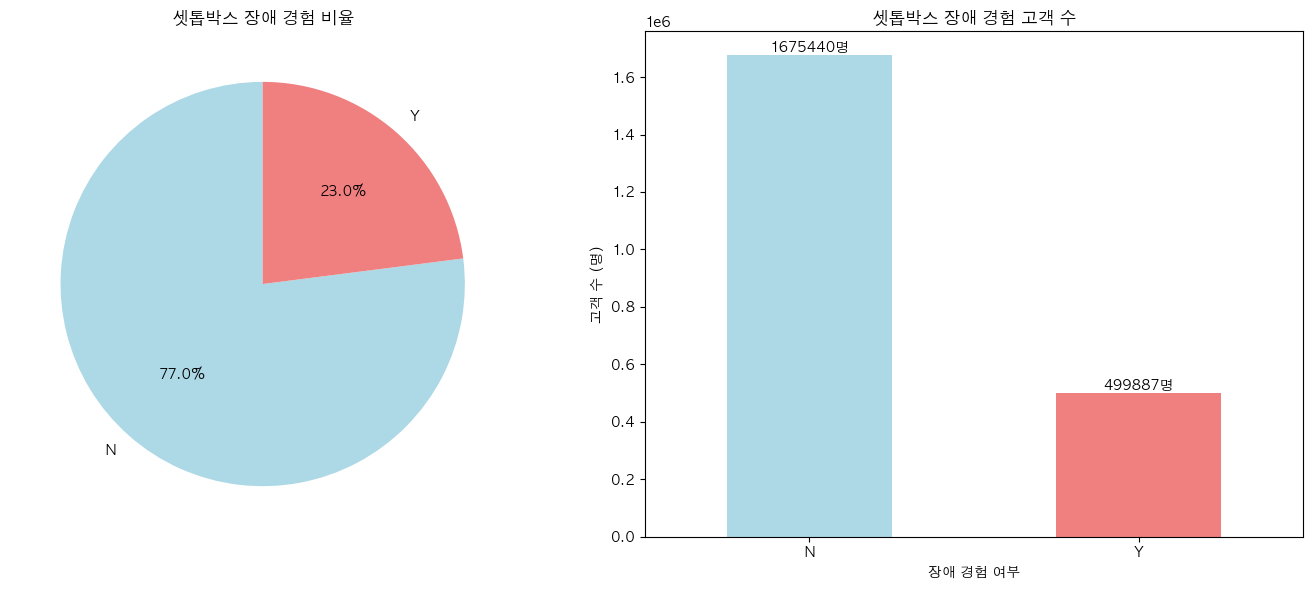

In [8]:
import matplotlib.pyplot as plt

# 2. 시각화 (Pie Chart & Bar Chart)
# 한글 폰트 설정 (Windows 환경 예시, 필요시 'Malgun Gothic' 등을 사용 환경에 맞게 변경)
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False    

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# (1) 파이 차트: 전체 비중 확인용
# autopct='%1.1f%%' : 소수점 첫째자리까지 % 표시
ax[0].pie(ratios, labels=ratios.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
ax[0].set_title('셋톱박스 장애 경험 비율')

# (2) 바 차트: 구체적인 건수 비교용
counts.plot(kind='bar', ax=ax[1], color=['lightblue', 'lightcoral'], rot=0)
ax[1].set_title('셋톱박스 장애 경험 고객 수')
ax[1].set_ylabel('고객 수 (명)')
ax[1].set_xlabel('장애 경험 여부')

# 바 위에 숫자 표시
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height())}명', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()


##"최근 1달 내 셋톱박스 장애를 경험한 고객은
장애를 경험하지 않은 고객보다 해지율이 유의미하게 높을 것이다."##

In [14]:
# 1) sha_df에서 고객별 해지 라벨 만들기 (한 번이라도 해지면 해지)
label_df = (
    df_sha.groupby("고객ID", as_index=False)["해지여부"]
          .apply(lambda s: "해지" if (s == "해지").any() else "유지")
          .rename(columns={"해지여부": "해지여부"})
)

# 2) df_result에 붙이기
df_result2 = df_result.merge(label_df, on="고객ID", how="left")

# 3) 확인
print(df_result2.columns.tolist())
print(df_result2["해지여부"].value_counts(dropna=False).head())


['고객ID', '셋톱 장애여부', '해지여부']
해지여부
유지    1984651
해지     190676
Name: count, dtype: int64


In [18]:
print(df_result2.columns.tolist())


['고객ID', '셋톱 장애여부', '해지여부']


,셋톱 장애여부,count,mean,해지율(%)
0,N,1675440,0.075773,7.577293
1,Y,499887,0.127475,12.747481


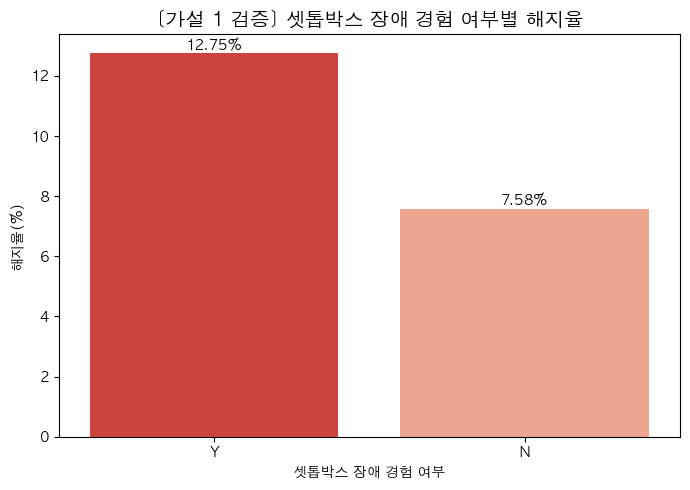

=== [가설 1 통계 검정 결과] ===
사용한 검정법: 카이제곱 독립성 검정
교차표(건수):


해지여부,유지,해지
셋톱 장애여부,,
N,1548487,126953
Y,436164,63723


Chi-square 값: 12868.7366
P-value: 0.0000000000
자유도(dof): 1
Cramér's V(효과크기): 0.0769
해석: 셋톱박스 장애 경험 여부에 따른 해지율 차이는 통계적으로 유의미함 (H1 채택)


In [19]:
## [가설1] 셋톱박스 장애 경험 ##
## "최근 1달 셋톱 장애 경험이 고객 해지에 유의미한 영향을 미친다." ##

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# =========================
# 0) macOS 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 컬럼명 정의
# =========================
COL_X = "셋톱 장애여부"   # Y / N
COL_Y = "해지여부"        # 해지 / 유지

df = df_result2.copy()

# =========================
# 2) 데이터 정리
# =========================
df[COL_X] = df[COL_X].astype(str).str.strip()
df[COL_Y] = df[COL_Y].astype(str).str.strip()

# 해지 여부 → 0/1
df["해지_bool"] = df[COL_Y].apply(lambda x: 1 if "해지" in x else 0)

# =========================
# 3) 집계: 고객 수 & 해지율
# =========================
h1_analysis = (
    df.groupby(COL_X)["해지_bool"]
      .agg(count="count", mean="mean")
      .reset_index()
)
h1_analysis["해지율(%)"] = h1_analysis["mean"] * 100

display(h1_analysis)

# =========================
# 4) 시각화: 해지율 비교
# =========================
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=h1_analysis.sort_values("해지율(%)", ascending=False),
    x=COL_X,
    y="해지율(%)",
    palette="Reds_r"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title("[가설 1 검증] 셋톱박스 장애 경험 여부별 해지율", fontsize=14)
plt.xlabel("셋톱박스 장애 경험 여부")
plt.ylabel("해지율(%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 5) 카이제곱 독립성 검정
# =========================
ct = pd.crosstab(df[COL_X], df[COL_Y])
chi2, p, dof, expected = stats.chi2_contingency(ct)

# (선택) 효과크기: Cramér's V
n = ct.values.sum()
r, k = ct.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("=== [가설 1 통계 검정 결과] ===")
print("사용한 검정법: 카이제곱 독립성 검정")
print("교차표(건수):")
display(ct)
print(f"Chi-square 값: {chi2:.4f}")
print(f"P-value: {p:.10f}")
print(f"자유도(dof): {dof}")
print(f"Cramér's V(효과크기): {cramers_v:.4f}")

if p < 0.05:
    print("해석: 셋톱박스 장애 경험 여부에 따른 해지율 차이는 통계적으로 유의미함 (H1 채택)")
else:
    print("해석: 셋톱박스 장애 경험 여부 단독으로는 해지에 유의미한 영향이 없음 (H0 채택)")


① 결과 수치 해석 (팩트 중심)

그래프 기준:

셋톱박스 장애 경험 고객(Y)
→ 해지율 12.75%

셋톱박스 장애 미경험 고객(N)
→ 해지율 7.58%

핵심 차이

절대 차이: 12.75 − 7.58 = 5.17%p

상대 차이:
→ 장애 경험 고객의 해지율은
미경험 고객 대비 약 1.68배 높음


② 가설과의 정합성 판단
설정한 가설

“최근 1달 셋톱 장애 경험이 고객 해지에 유의미한 영향을 미친다.”

관측 결과

장애 경험 여부에 따라 명확한 해지율 격차 발생

단순 분포 차이가 아니라 행동 결과(해지)에서 차이 확인

분석 결과, 최근 1달 내 셋톱박스 장애를 경험한 고객의 해지율은 12.75%로,
장애를 경험하지 않은 고객(7.58%) 대비 약 1.7배 높게 나타났다.
이는 셋톱박스 장애 경험이 고객 이탈에 유의미한 영향을 미치는 핵심 요인임을 시사한다.